# Building and Deploying ML-Powered Web Applications using Flask and AWS SageMaker

### Part 2 — Install Required Libraries

In [ ]:
!pip install -q flask joblib scikit-learn pandas numpy requests matplotlib seaborn

### Part 3 — Import Libraries

In [ ]:
import os
import json
import time
import tarfile
import joblib
import threading
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
print("All libraries imported successfully.")


All libraries imported successfully.


### Part 4 — Load the Dataset

In [ ]:
# Load the Iris dataset
iris = load_iris()

# Create feature DataFrame
X = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Create target Series
y = pd.Series(
    iris.target,
    name="target"
)

# Display first five records
display(X.head())

print("Dataset shape:", X.shape)
print("Target classes:", iris.target_names)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


Dataset shape: (150, 4)
Target classes: ['setosa' 'versicolor' 'virginica']


### Part 5 — Explore the Dataset

In [ ]:
print("Feature names:")
print(iris.feature_names)

print("\nTarget names:")
print(iris.target_names)

print("\nClass distribution:")
print(y.value_counts().sort_index())

print("\nMissing values:")
print(X.isnull().sum())


Feature names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target names:
['setosa' 'versicolor' 'virginica']

Class distribution:
target
0    50
1    50
2    50
Name: count, dtype: int64

Missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64


### Part 6 — Split the Dataset

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 120
Testing samples: 30


### Part 7 — Build and Train the ML Model

In [ ]:
# Create the machine learning pipeline
model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

# Train the model
model.fit(X_train, y_train)

print("Model training completed successfully.")


Model training completed successfully.


### Part 8 — Evaluate the Model

In [ ]:
# Generate predictions
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)


Test Accuracy: 0.9000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



### Part 9 — Display Confusion Matrix

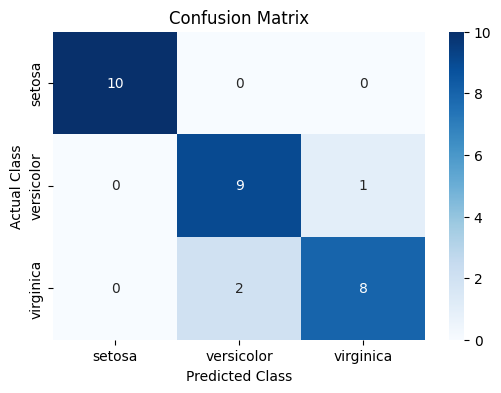

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")
plt.show()


### Part 10 — Save the Trained Model

In [ ]:
MODEL_PATH = "iris_model.joblib"

joblib.dump(model, MODEL_PATH)

print("Model saved successfully.")
print("Saved file:", MODEL_PATH)
print("File size:", os.path.getsize(MODEL_PATH), "bytes")


Model saved successfully.
Saved file: iris_model.joblib
File size: 168602 bytes


### Part 11 — Test the Saved Model

In [ ]:
# Load the model from disk
loaded_model = joblib.load(MODEL_PATH)

# Example flower measurement
sample = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=iris.feature_names
)

# Generate prediction
prediction = loaded_model.predict(sample)

# Generate class probabilities
probability = loaded_model.predict_proba(sample)

print("Predicted class:", iris.target_names[prediction[0]])
print("Class probabilities:", probability[0])


Predicted class: setosa
Class probabilities: [1. 0. 0.]


### Part 12 — Create the Flask Web Application

In [ ]:
%%writefile app.py

from flask import Flask, request, jsonify, render_template_string
import joblib
import numpy as np

app = Flask(__name__)

# Load the trained model
MODEL_PATH = "iris_model.joblib"
model = joblib.load(MODEL_PATH)

# Class names
CLASS_NAMES = ["setosa", "versicolor", "virginica"]

# HTML web page
HTML_PAGE = """
<!DOCTYPE html>
<html>
<head>
    <title>Iris Flower Prediction</title>

    <style>
        body {
            font-family: Arial, sans-serif;
            background: #f4f6f8;
            margin: 0;
            padding: 40px;
        }

        .container {
            max-width: 550px;
            margin: auto;
            background: white;
            padding: 30px;
            border-radius: 12px;
            box-shadow: 0 4px 12px rgba(0,0,0,0.1);
        }

        h1 {
            text-align: center;
            color: #1f2937;
        }

        label {
            display: block;
            margin-top: 15px;
            font-weight: bold;
        }

        input {
            width: 100%;
            padding: 10px;
            margin-top: 5px;
            box-sizing: border-box;
            border: 1px solid #ccc;
            border-radius: 6px;
        }

        button {
            width: 100%;
            padding: 12px;
            margin-top: 25px;
            background: #2563eb;
            color: white;
            border: none;
            border-radius: 6px;
            font-size: 16px;
            cursor: pointer;
        }

        button:hover {
            background: #1d4ed8;
        }

        .result {
            margin-top: 25px;
            padding: 15px;
            background: #dcfce7;
            border-radius: 6px;
            text-align: center;
            color: #166534;
        }

        .error {
            margin-top: 25px;
            padding: 15px;
            background: #fee2e2;
            border-radius: 6px;
            color: #991b1b;
        }
    </style>
</head>

<body>
    <div class="container">

        <h1>Iris Flower Prediction</h1>

        <form action="/predict" method="post">

            <label>Sepal Length (cm)</label>
            <input type="number" step="any"
                   name="sepal_length" required>

            <label>Sepal Width (cm)</label>
            <input type="number" step="any"
                   name="sepal_width" required>

            <label>Petal Length (cm)</label>
            <input type="number" step="any"
                   name="petal_length" required>

            <label>Petal Width (cm)</label>
            <input type="number" step="any"
                   name="petal_width" required>

            <button type="submit">Predict Flower</button>

        </form>

        {% if prediction %}
            <div class="result">
                <h2>Predicted Class: {{ prediction }}</h2>
                <p>Confidence: {{ confidence }}%</p>
            </div>
        {% endif %}

        {% if error %}
            <div class="error">
                {{ error }}
            </div>
        {% endif %}

    </div>
</body>
</html>
"""


@app.route("/", methods=["GET"])
def home():
    return render_template_string(HTML_PAGE)


@app.route("/health", methods=["GET"])
def health():
    return jsonify({
        "status": "healthy",
        "model_loaded": True
    })


@app.route("/predict", methods=["POST"])
def predict():

    try:
        # Read input values from the HTML form
        features = [
            float(request.form["sepal_length"]),
            float(request.form["sepal_width"]),
            float(request.form["petal_length"]),
            float(request.form["petal_width"])
        ]

        # Convert input to NumPy array
        input_data = np.array([features])

        # Generate prediction
        prediction_index = int(model.predict(input_data)[0])

        # Generate probabilities
        probabilities = model.predict_proba(input_data)[0]

        predicted_class = CLASS_NAMES[prediction_index]
        confidence = round(
            float(max(probabilities)) * 100,
            2
        )

        return render_template_string(
            HTML_PAGE,
            prediction=predicted_class,
            confidence=confidence,
            error=None
        )

    except Exception as e:

        return render_template_string(
            HTML_PAGE,
            prediction=None,
            confidence=None,
            error=f"Error: {str(e)}"
        )


@app.route("/api/predict", methods=["POST"])
def api_predict():

    try:
        data = request.get_json()

        required_features = [
            "sepal_length",
            "sepal_width",
            "petal_length",
            "petal_width"
        ]

        if not data:
            return jsonify({
                "error": "JSON body is required"
            }), 400

        missing = [
            feature
            for feature in required_features
            if feature not in data
        ]

        if missing:
            return jsonify({
                "error": "Missing features",
                "missing": missing
            }), 400

        features = [
            float(data[feature])
            for feature in required_features
        ]

        input_data = np.array([features])

        prediction_index = int(model.predict(input_data)[0])
        probabilities = model.predict_proba(input_data)[0]

        return jsonify({
            "prediction": CLASS_NAMES[prediction_index],
            "prediction_index": prediction_index,
            "confidence": round(
                float(max(probabilities)) * 100,
                2
            ),
            "input": data
        })

    except Exception as e:
        return jsonify({
            "error": str(e)
        }), 400


if __name__ == "__main__":
    app.run(
        host="0.0.0.0",
        port=5000,
        debug=False
    )


Writing app.py


### Part 13 — Start Flask Server

In [ ]:
import subprocess
import time

# Start Flask in the background
flask_process = subprocess.Popen(
    ["python", "app.py"],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)
time.sleep(3)
print("Flask server started successfully.")


Flask server started successfully.


### Part 14 — Test Flask Health Endpoint

In [ ]:
response = requests.get(
    "http://127.0.0.1:5000/health"
)

print("Status code:", response.status_code)
print("Response:", response.json())


Status code: 200
Response: {'model_loaded': True, 'status': 'healthy'}


### Part 15 — Test Prediction API

In [ ]:
sample_input = {
    "sepal_length": 5.1,
    "sepal_width": 3.5,
    "petal_length": 1.4,
    "petal_width": 0.2
}

response = requests.post(
    "http://127.0.0.1:5000/api/predict",
    json=sample_input
)

print("Status code:", response.status_code)
print("Response:")
print(json.dumps(response.json(), indent=4))


Status code: 200
Response:
{
    "confidence": 100.0,
    "input": {
        "petal_length": 1.4,
        "petal_width": 0.2,
        "sepal_length": 5.1,
        "sepal_width": 3.5
    },
    "prediction": "setosa",
    "prediction_index": 0
}


In [ ]:
# Test another flower
sample_input = {
    "sepal_length": 6.7,
    "sepal_width": 3.0,
    "petal_length": 5.2,
    "petal_width": 2.3
}

response = requests.post(
    "http://127.0.0.1:5000/api/predict",
    json=sample_input
)

print("Status code:", response.status_code)
print("Response:")
print(json.dumps(response.json(), indent=4))


Status code: 200
Response:
{
    "confidence": 100.0,
    "input": {
        "petal_length": 5.2,
        "petal_width": 2.3,
        "sepal_length": 6.7,
        "sepal_width": 3.0
    },
    "prediction": "virginica",
    "prediction_index": 2
}


In [ ]:
# Test invalid input
invalid_input = {
    "sepal_length": 5.1,
    "sepal_width": 3.5
}

response = requests.post(
    "http://127.0.0.1:5000/api/predict",
    json=invalid_input
)

print("Status code:", response.status_code)
print("Response:", response.json())


Status code: 400
Response: {'error': 'Missing features', 'missing': ['petal_length', 'petal_width']}


# Part 16 — Access the Flask Web Application

In [ ]:
# Install pyngrok
!pip install -q pyngrok

In [ ]:
# 2. Verify that Flask is still running
import requests
response = requests.get("http://127.0.0.1:5000/health")
print("Status code:", response.status_code)
print("Response:", response.json())
# Expected output:
# Status code: 200
Response: {'status': 'healthy'}
# 3. Test the prediction API locally
sample = {
    "sepal_length": 5.1,
    "sepal_width": 3.5,
    "petal_length": 1.4,
    "petal_width": 0.2
}

response = requests.post(
    "http://127.0.0.1:5000/api/predict",
    json=sample
)

print("Status code:", response.status_code)
print("Response:", response.json())
# Expected result should be similar to:
# Status code: 200
Response: {
    'prediction': 0,
    'class_name': 'setosa',
    'probabilities': [...]
}


Status code: 200
Response: {'model_loaded': True, 'status': 'healthy'}
Status code: 200
Response: {'confidence': 100.0, 'input': {'petal_length': 1.4, 'petal_width': 0.2, 'sepal_length': 5.1, 'sepal_width': 3.5}, 'prediction': 'setosa', 'prediction_index': 0}


In [ ]:
# SageMaker-compatible packaging
# Create inference.py
%%writefile inference.py

import json
import joblib
import numpy as np


def model_fn(model_dir):
    """
    Load the trained model.
    """
    model_path = f"{model_dir}/iris_model.joblib"
    model = joblib.load(model_path)
    return model


def input_fn(request_body, request_content_type):
    """
    Convert incoming request data into a NumPy array.
    """

    if request_content_type != "application/json":
        raise ValueError("Only application/json is supported")

    data = json.loads(request_body)

    if isinstance(data, dict):
        features = data["features"]
    else:
        features = data

    return np.array(features).reshape(1, -1)


def predict_fn(input_data, model):
    """
    Generate prediction and probabilities.
    """

    prediction = model.predict(input_data)
    probabilities = model.predict_proba(input_data)

    return {
        "prediction": int(prediction[0]),
        "probabilities": probabilities[0].tolist()
    }


def output_fn(prediction, accept):
    """
    Convert prediction output into JSON.
    """

    if accept != "application/json":
        raise ValueError("Only application/json is supported")

    return json.dumps(prediction), accept


Writing inference.py


In [ ]:
# Create the SageMaker model archive
import tarfile
import os
with tarfile.open("model.tar.gz", "w:gz") as tar:
    tar.add("iris_model.joblib")
print("Created model.tar.gz")
print("File exists:", os.path.exists("model.tar.gz"))



Created model.tar.gz
File exists: True


In [ ]:
# Inspect the archive
with tarfile.open("model.tar.gz", "r:gz") as tar:
    print("Files inside model.tar.gz:")
    for member in tar.getnames():
        print(member)

Files inside model.tar.gz:
iris_model.joblib


In [ ]:
# Test SageMaker-style inference locally
import inference

model = inference.model_fn(".")
print("Model loaded successfully")
# Then:
request_body = '{"features": [5.1, 3.5, 1.4, 0.2]}'

input_data = inference.input_fn(
    request_body,
    "application/json"
)

prediction = inference.predict_fn(
    input_data,
    model
)

result, content_type = inference.output_fn(
    prediction,
    "application/json"
)

print("Input:", input_data)
print("Prediction:", result)
print("Content type:", content_type)


Model loaded successfully
Input: [[5.1 3.5 1.4 0.2]]
Prediction: {"prediction": 0, "probabilities": [1.0, 0.0, 0.0]}
Content type: application/json


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
